In [1]:
import random
import torch
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
import matplotlib.pyplot as plt

from attack import fgsm_targeted, fgsm_untargeted, pgd_targeted, pgd_untargeted, margin_loss, _compute_loss
from models import MNIST_Net, CIFAR_Net

device = "cuda" if torch.cuda.is_available() else "cpu"

torch.manual_seed(42)
random.seed(42)

In [2]:
DATASETS = ["MNIST", "CIFAR10"]
NUM_SAMPLES = 5

LOSS_LIST = ["ce", "mse", "kl", "margin"]

ATTACK_CONFIG = {
    "MNIST": {"eps": 0.3, "k": 20, "eps_step": 0.01},
    "CIFAR10": {"eps": 0.03, "k": 20, "eps_step": 0.007},
}

CKPT_PATHS = {
    "MNIST": './ckpt/mnist.pth',
    "CIFAR10": './ckpt/cifar.pth',
}

In [3]:
to_pil = T.ToPILImage()

def tensor_to_pil(x):
    return to_pil(x.detach().cpu().clamp(0, 1))

def get_dataset_and_model(name):
    if name == "MNIST":
        dataset = torchvision.datasets.MNIST(
            root="./data", train=False, download=True, transform=T.ToTensor()
        )
        model = MNIST_Net()
    elif name == "CIFAR10":
        dataset = torchvision.datasets.CIFAR10(
            root="./data", train=False, download=True, transform=T.ToTensor()
        )
        model = CIFAR_Net()
    else:
        raise ValueError(f"Unsupported dataset: {name}")

    if CKPT_PATHS[name] is not None:
        model.load_state_dict(torch.load(CKPT_PATHS[name], map_location=device))

    return dataset, model.to(device).eval()

def get_samples(dataset, num_samples=5):
    indices = random.sample(range(len(dataset)), num_samples)
    return [(idx, dataset[idx]) for idx in indices]

def get_target(y, num_classes=10):
    target = torch.randint(0, num_classes, y.shape, device=device)
    target = (target + (target == y)) % num_classes
    return target

In [4]:
# Prediction / Success
def predict(model, x):
    with torch.no_grad():
        return model(x).argmax(1)

def success_untargeted(pred, y):
    return pred.item() != y.item()

def success_targeted(pred, target):
    return pred.item() == target.item()

In [5]:
# Generate attacks
def generate_attacks(model, x, y, dataset_name):
    cfg = ATTACK_CONFIG[dataset_name]
    eps = cfg["eps"]
    k = cfg["k"]
    eps_step = cfg["eps_step"]

    x = x.unsqueeze(0).to(device)
    y = torch.tensor([y], device=device)
    target = get_target(y)

    clean_pred = predict(model, x)

    results = {}

    for loss_name in LOSS_LIST:
        adv_fgsm_u = fgsm_untargeted(model, x, y, eps, criterion=loss_name)
        adv_fgsm_t = fgsm_targeted(model, x, target, eps, criterion=loss_name)
        adv_pgd_u  = pgd_untargeted(model, x, y, k, eps, eps_step, criterion=loss_name)
        adv_pgd_t  = pgd_targeted(model, x, target, k, eps, eps_step, criterion=loss_name)

        pred_fgsm_u = predict(model, adv_fgsm_u)
        pred_fgsm_t = predict(model, adv_fgsm_t)
        pred_pgd_u  = predict(model, adv_pgd_u)
        pred_pgd_t  = predict(model, adv_pgd_t)

        results[loss_name] = {
            "imgs": [x, adv_fgsm_u, adv_fgsm_t, adv_pgd_u, adv_pgd_t],
            "preds": [clean_pred, pred_fgsm_u, pred_fgsm_t, pred_pgd_u, pred_pgd_t],
            "success": [
                False,
                success_untargeted(pred_fgsm_u, y),
                success_targeted(pred_fgsm_t, target),
                success_untargeted(pred_pgd_u, y),
                success_targeted(pred_pgd_t, target),
            ],
        }

    return x, y, target, results

In [6]:
# Visualization

def visualize(x, y, target, results, dataset_name, idx, save_dir="./results"):
    import os
    os.makedirs(save_dir, exist_ok=True)

    n = len(LOSS_LIST)
    plt.figure(figsize=(15, 3 * n))

    titles = ["Original", "FGSM-U", "FGSM-T", "PGD-U", "PGD-T"]

    for r, loss_name in enumerate(LOSS_LIST):
        data = results[loss_name]
        imgs = data["imgs"]
        preds = data["preds"]
        success = data["success"]

        for c in range(5):
            plt.subplot(n, 5, r * 5 + c + 1)

            img = tensor_to_pil(imgs[c][0])

            if dataset_name == "MNIST":
                plt.imshow(img, cmap="gray")
            else:
                plt.imshow(img)

            pred = preds[c].item()

            if c == 0:
                title = f"{titles[c]}\nGT={y.item()} | pred={pred}"
                color = "black"
            else:
                mark = "✔" if success[c] else "✘"
                title = f"{titles[c]}\npred={pred} {mark}"
                color = "green" if success[c] else "red"

            plt.title(title, color=color, fontsize=9)

            if c == 0:
                plt.ylabel(loss_name, fontsize=11)

            plt.axis("off")

    plt.suptitle(
        f"{dataset_name} | idx={idx} | target={target.item()}",
        fontsize=13,
        fontweight="bold"
    )

    plt.tight_layout()

    filename = f"{dataset_name}_idx{idx}.png"
    plt.savefig(os.path.join(save_dir, filename))

    plt.show()
    plt.close()


===== MNIST =====


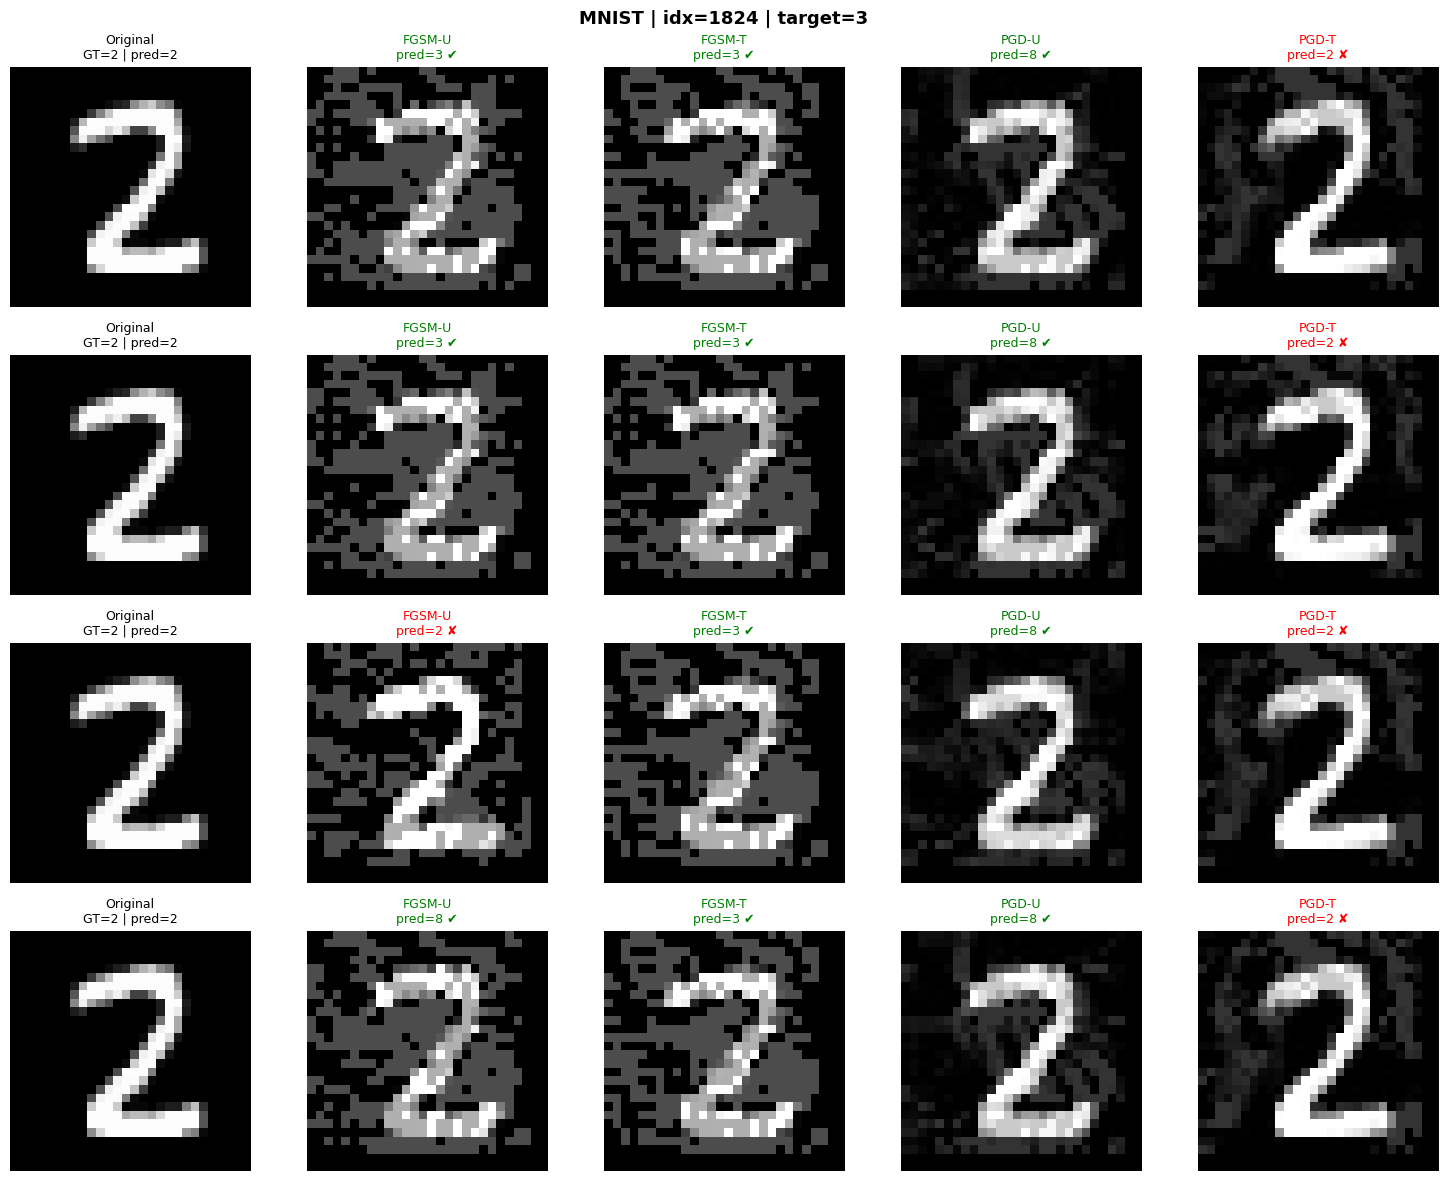

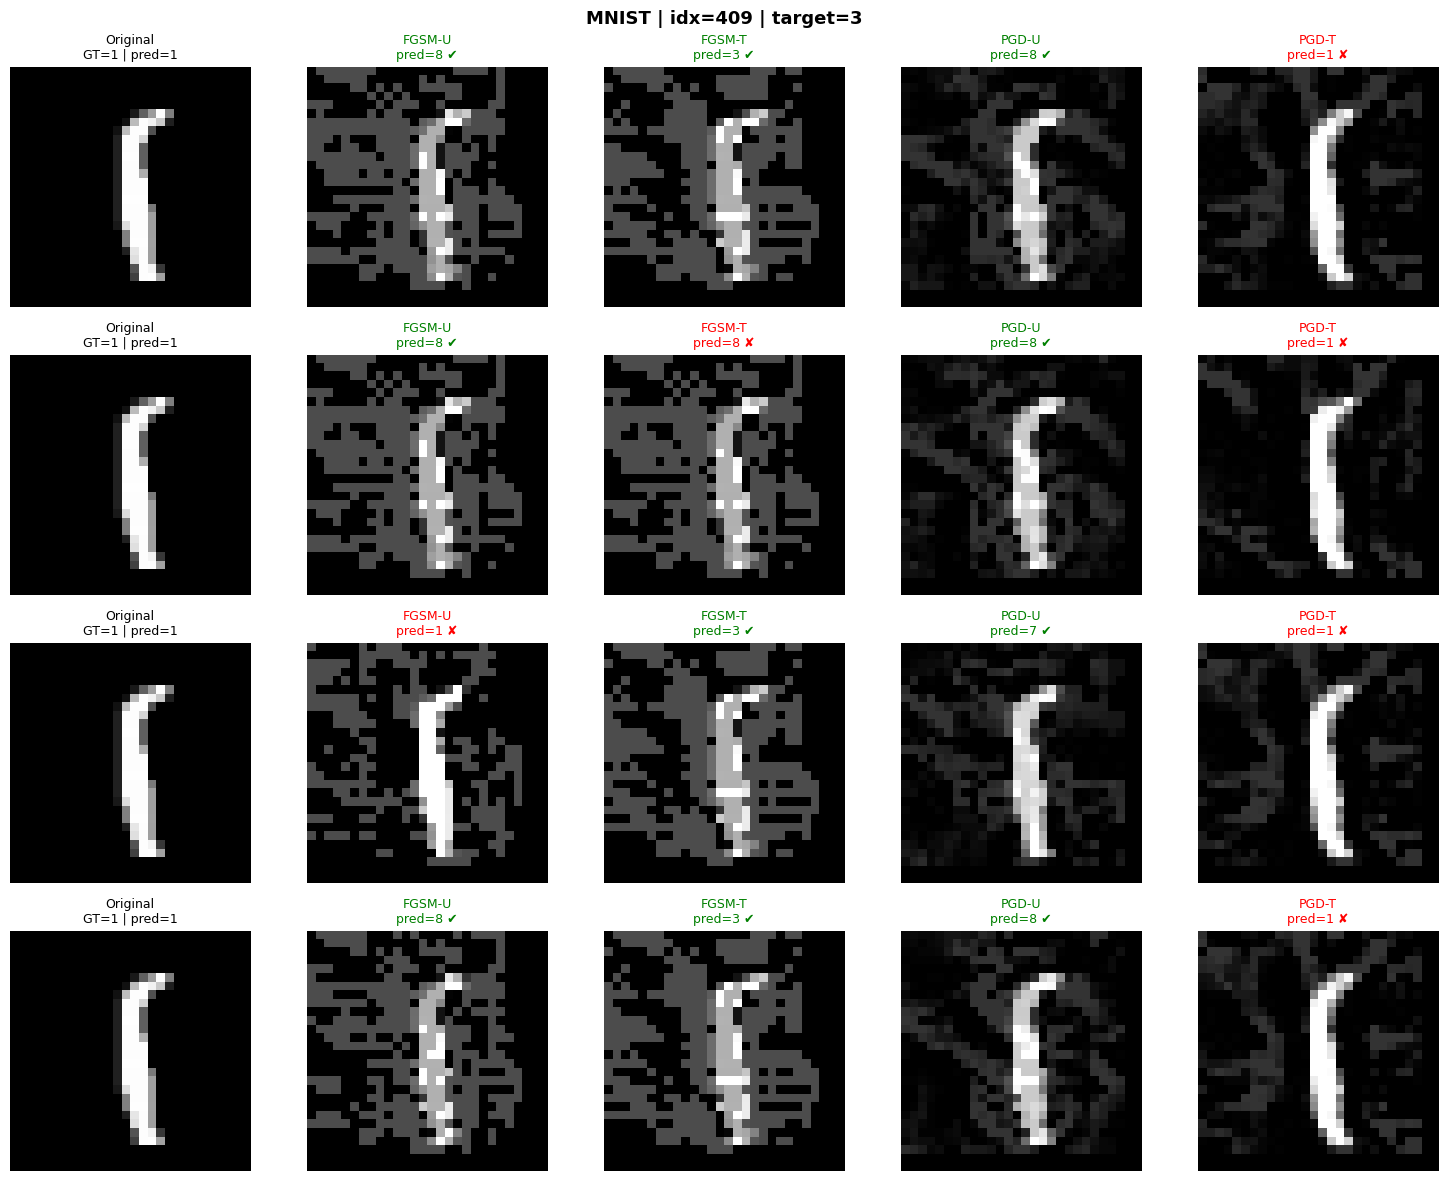

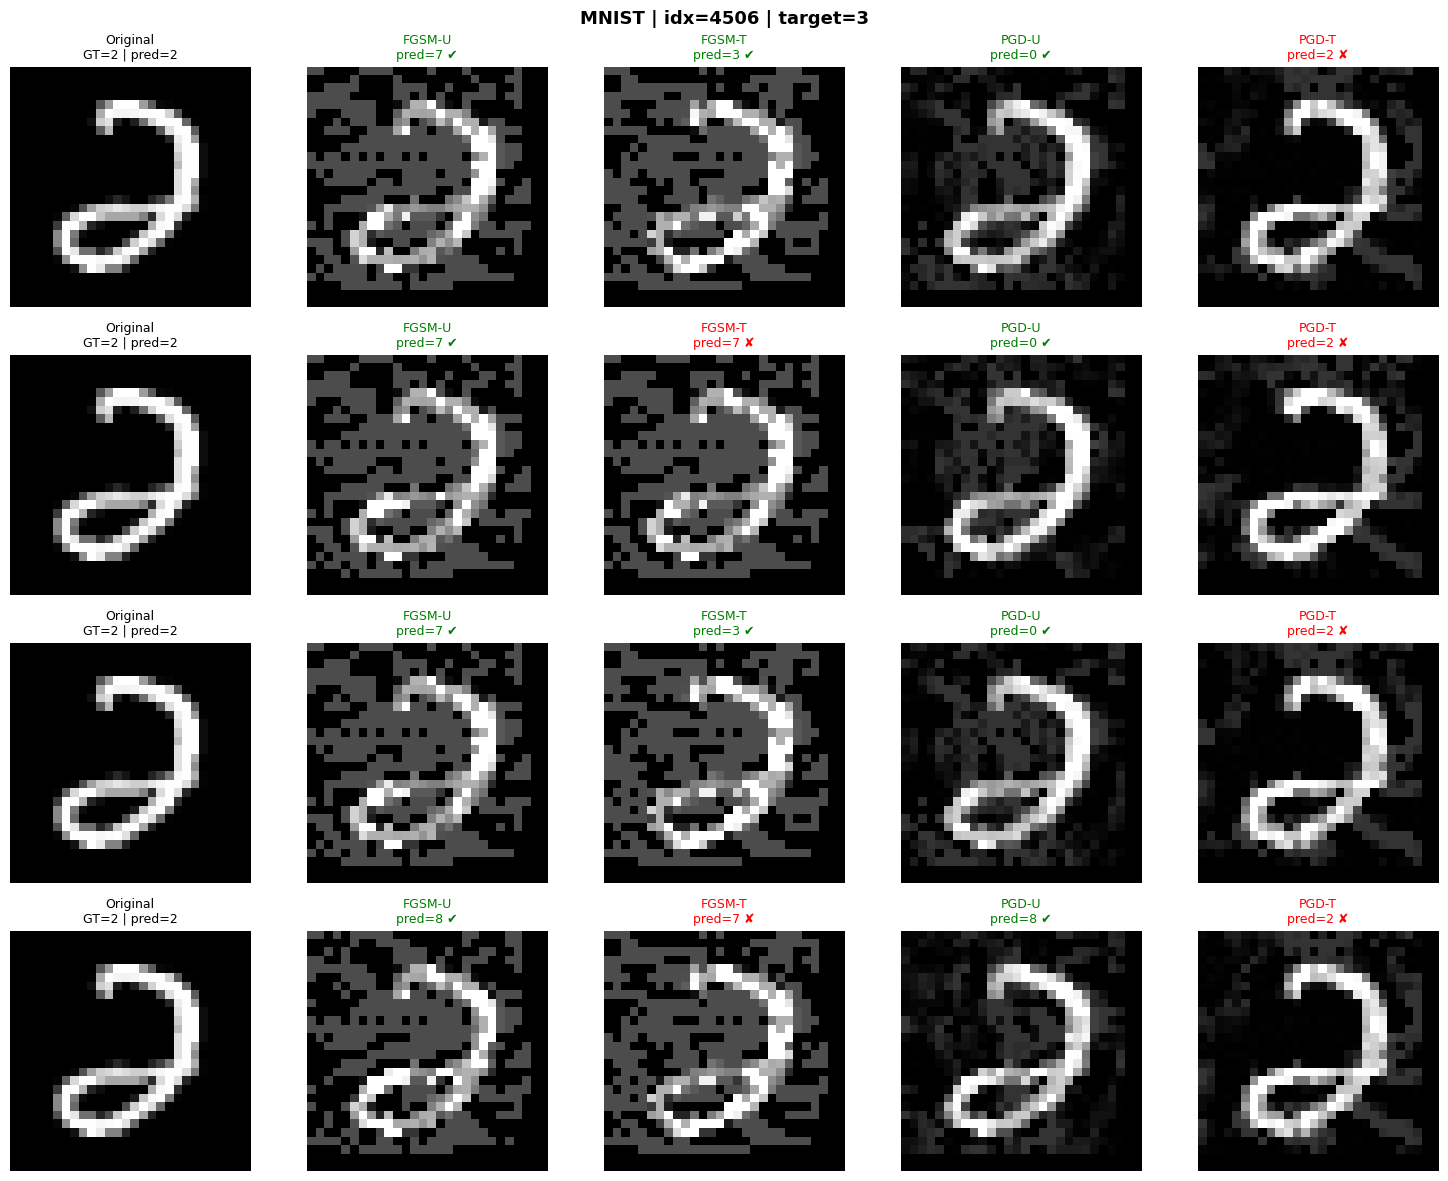

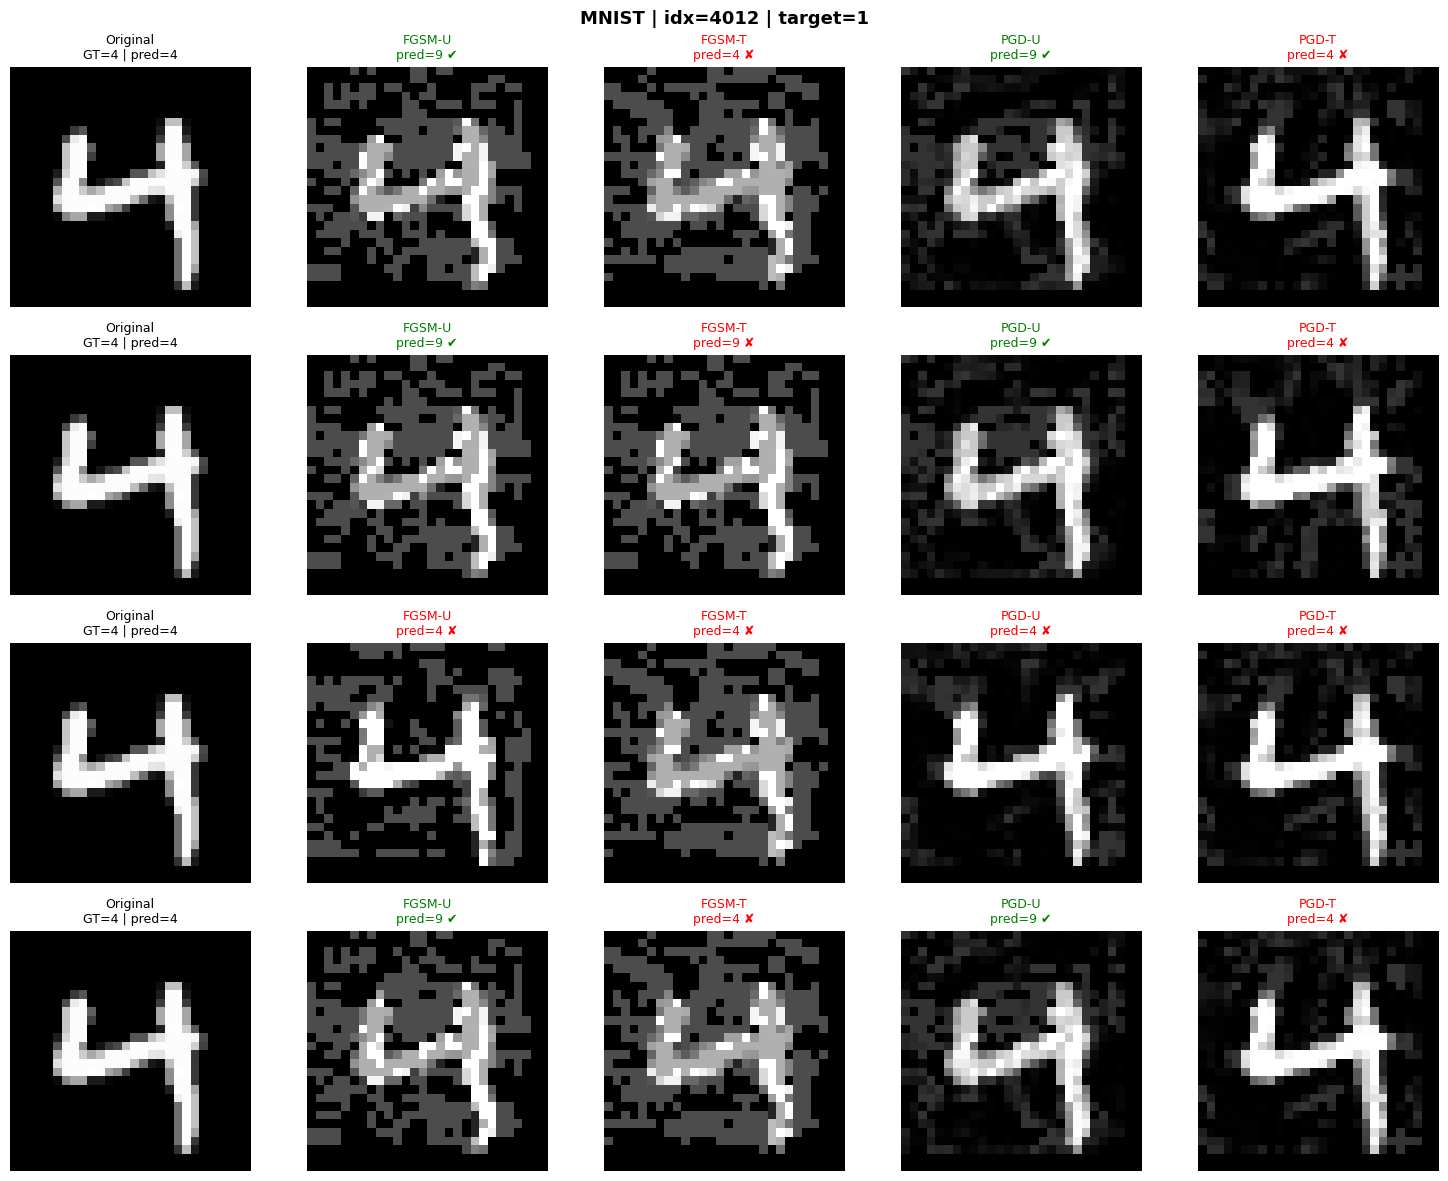

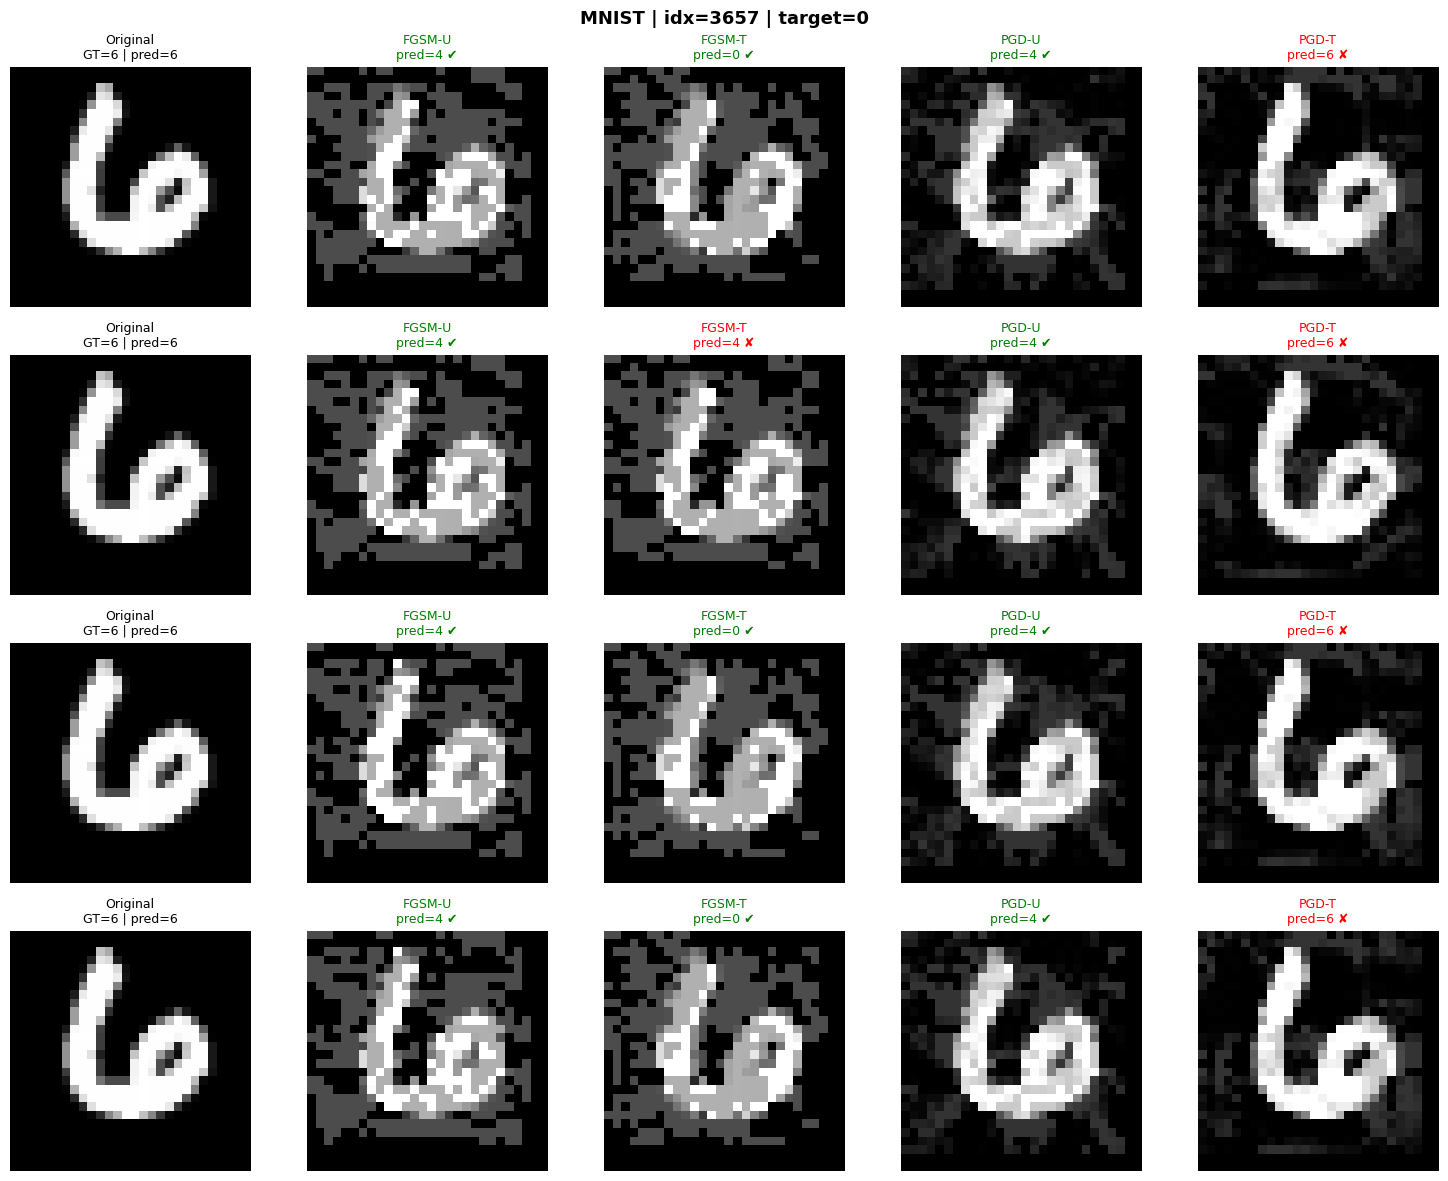


===== CIFAR10 =====
Files already downloaded and verified


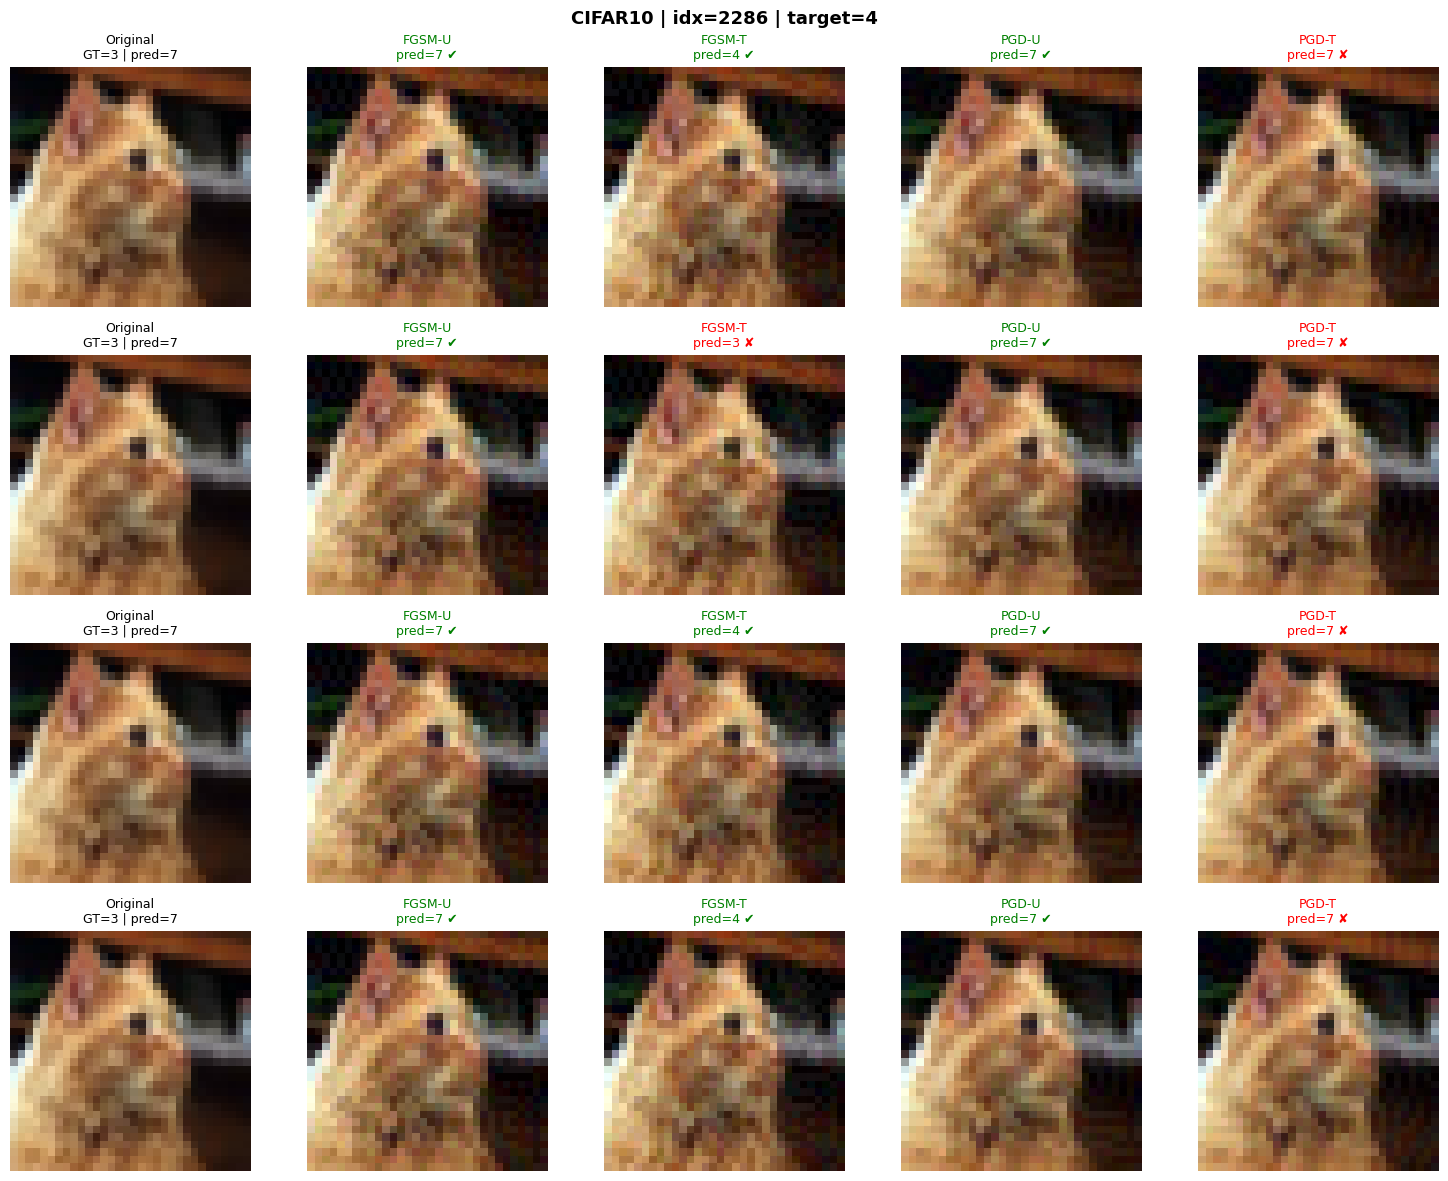

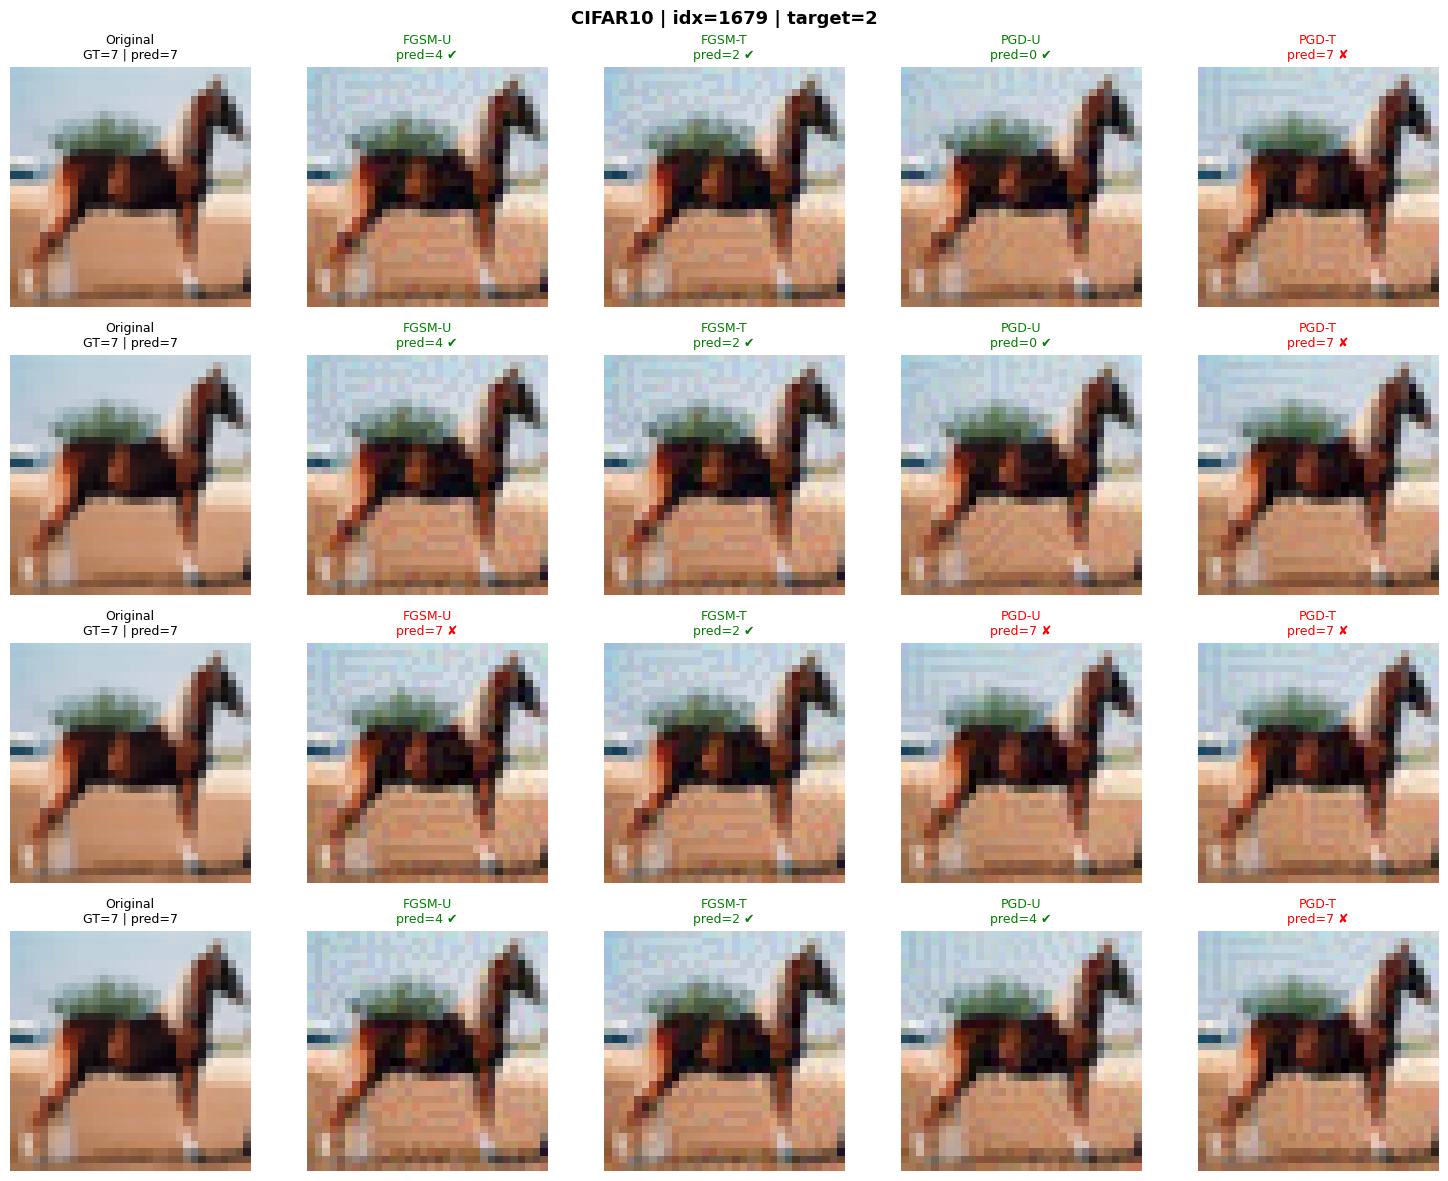

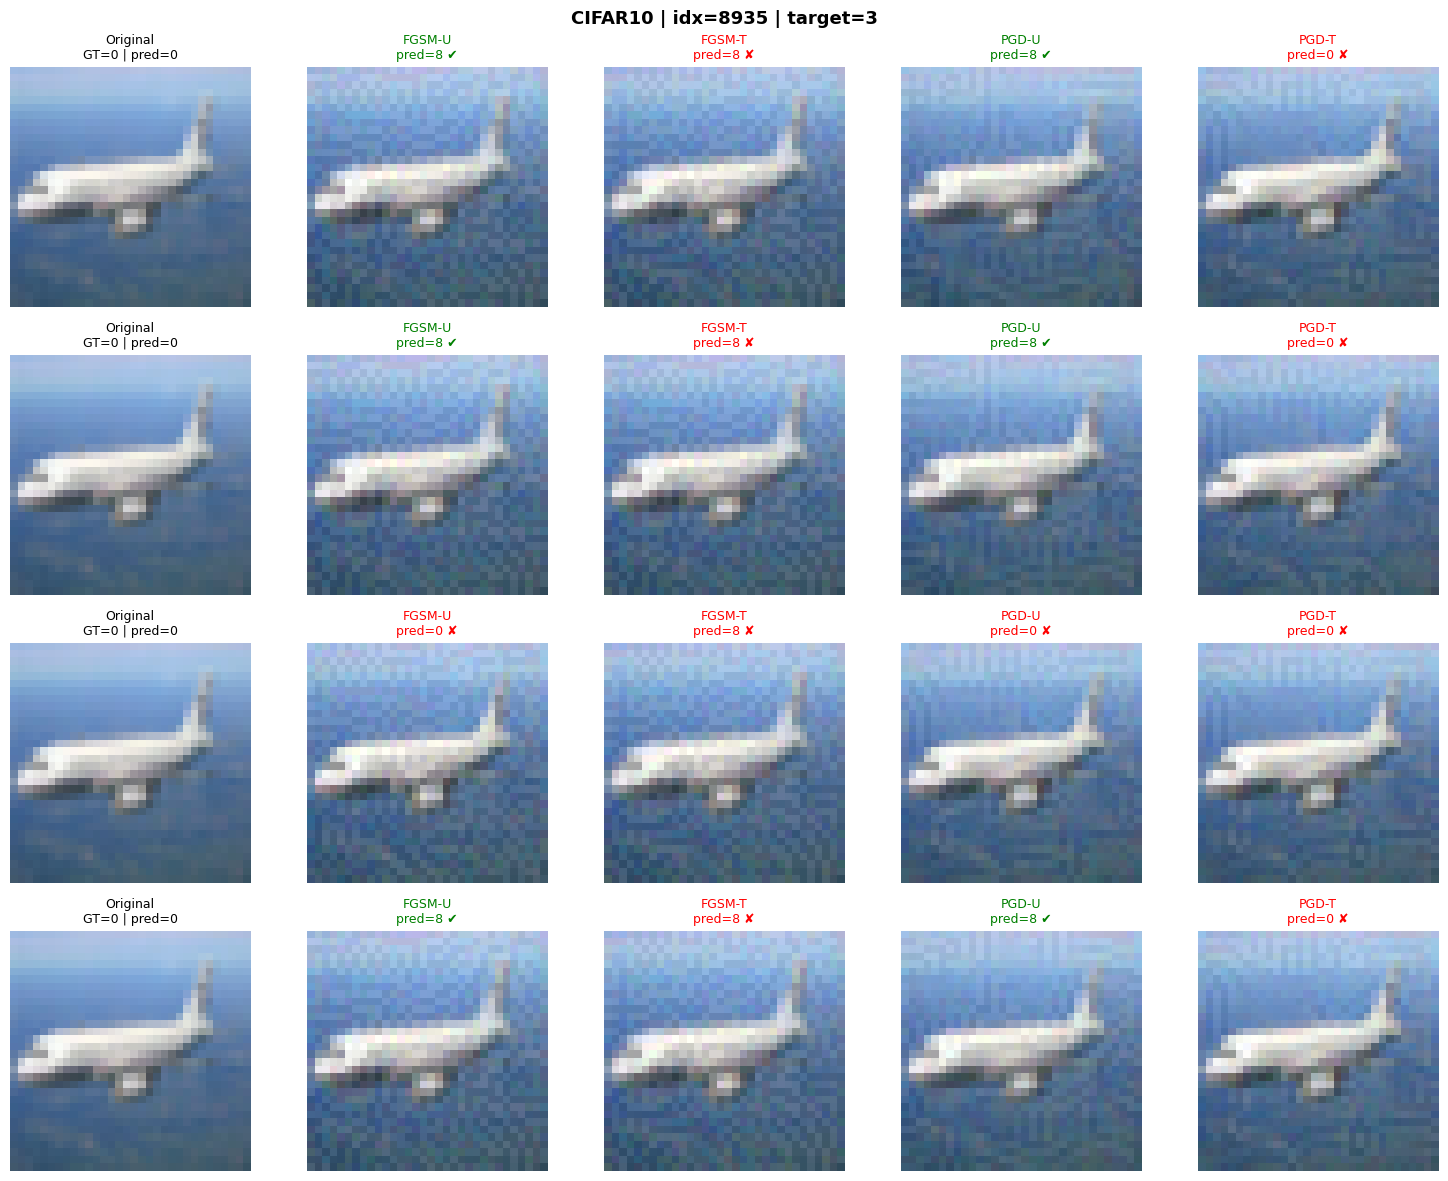

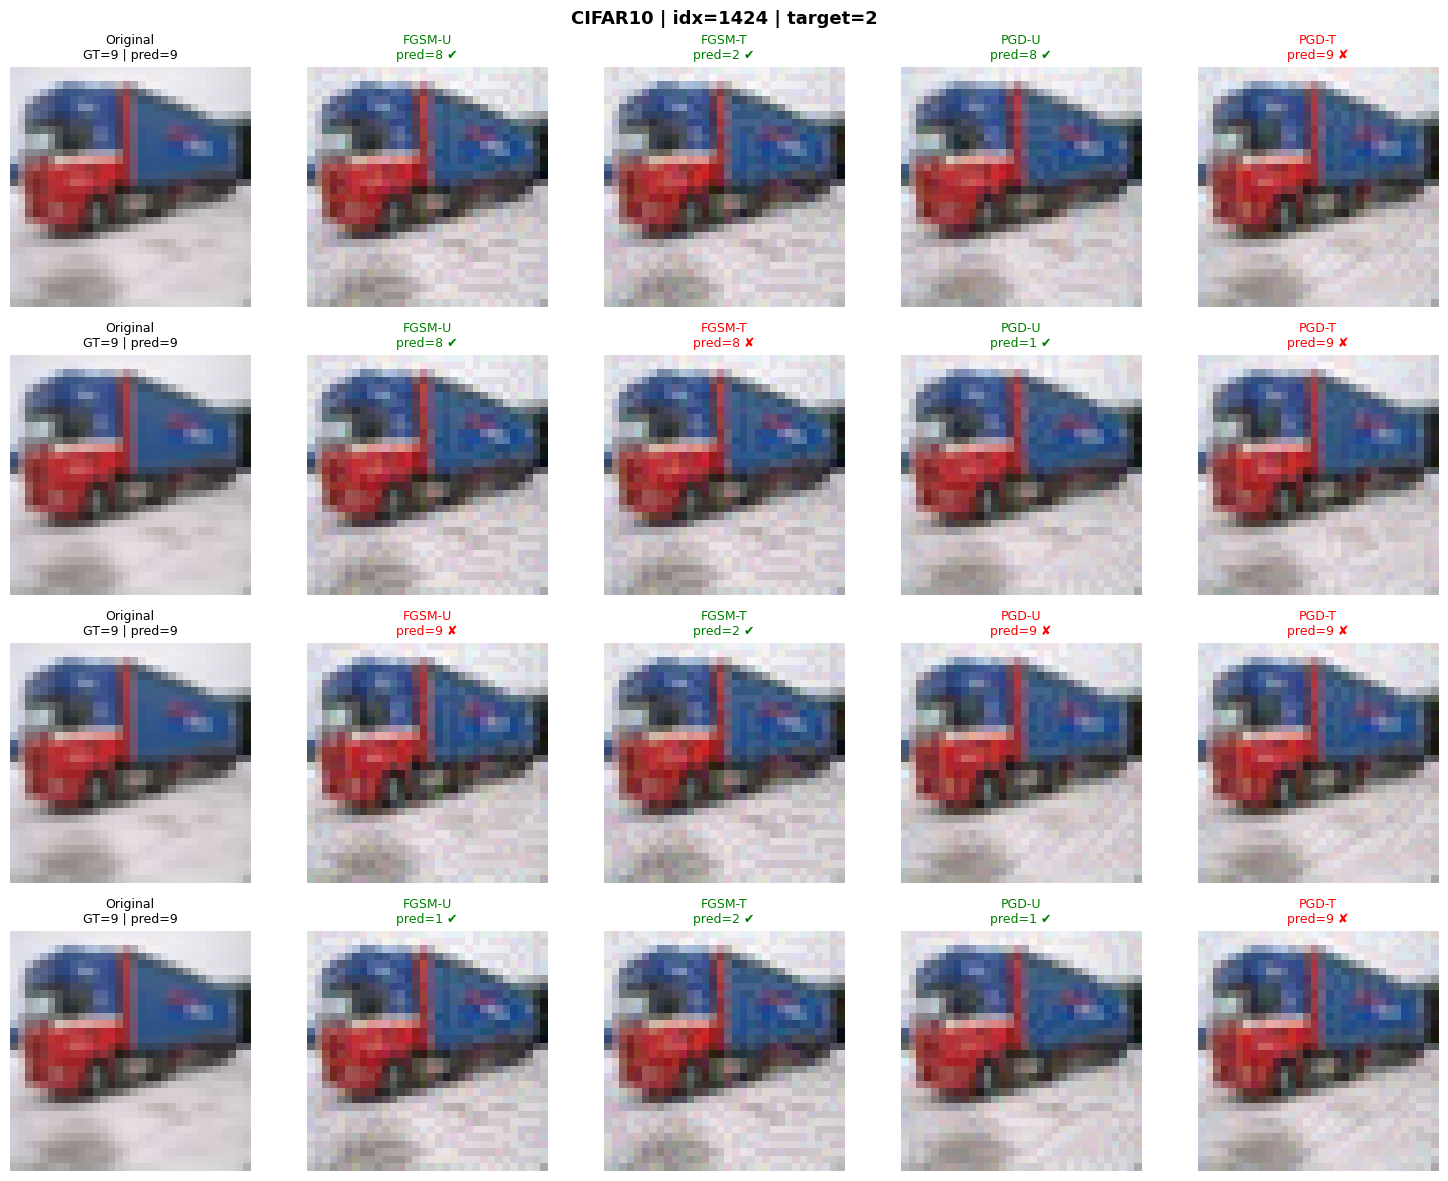

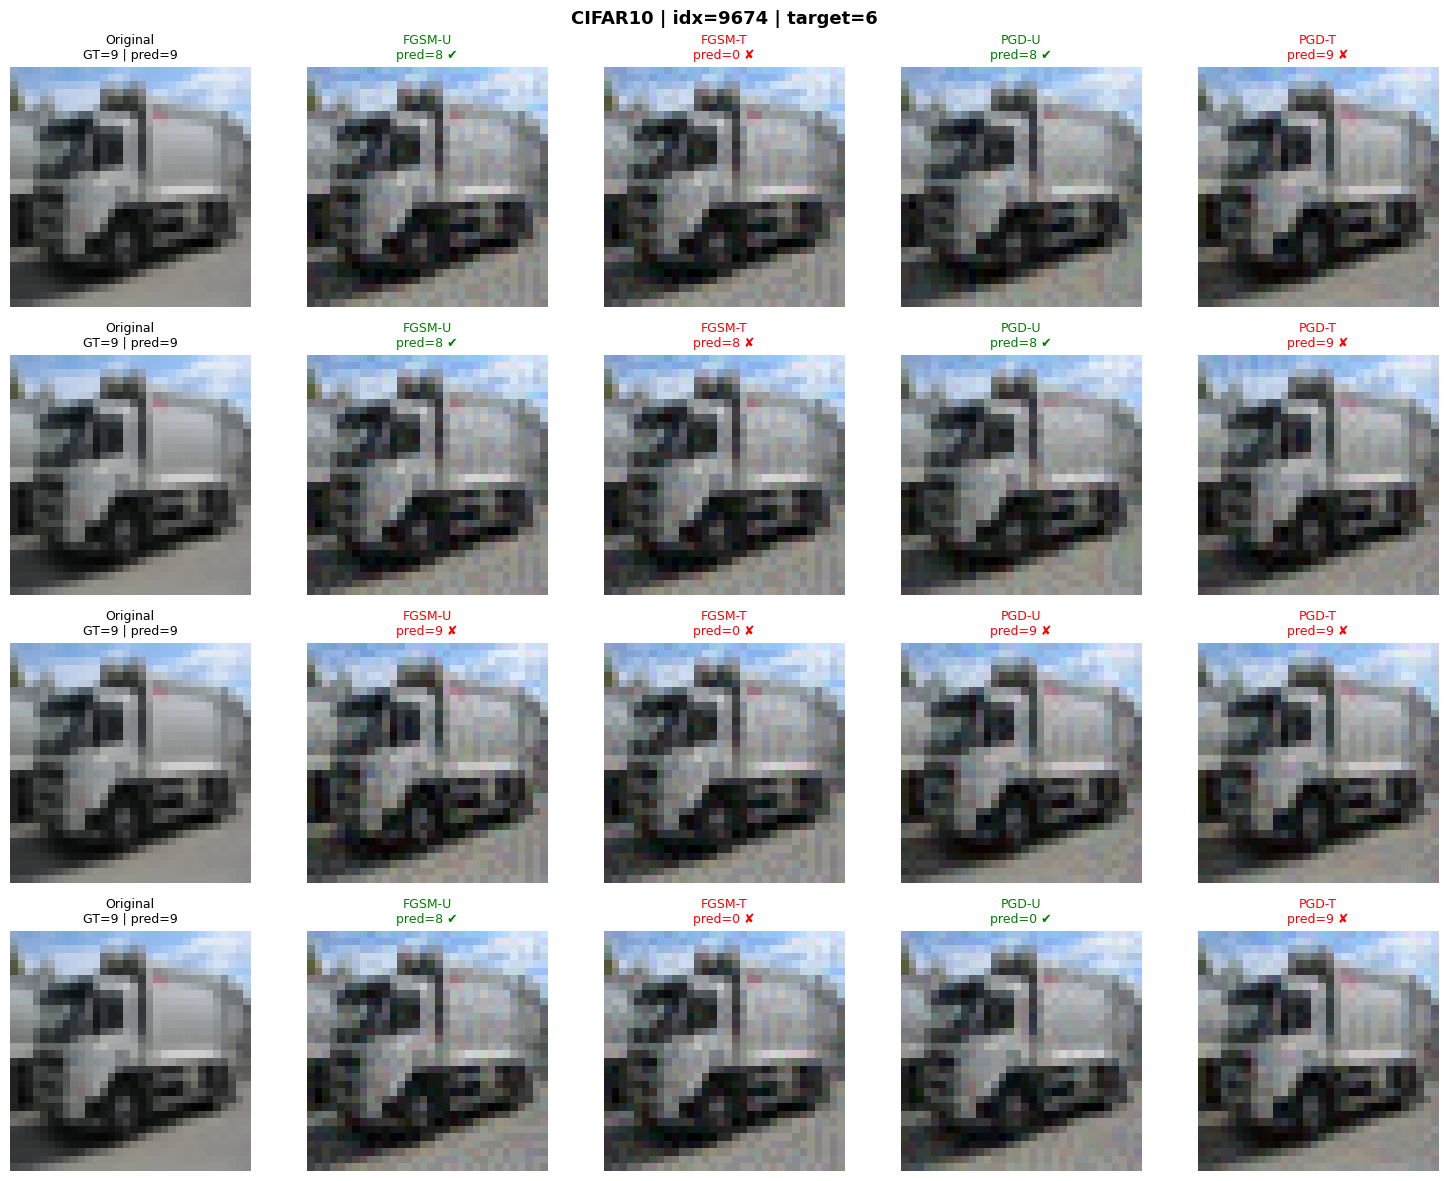

In [7]:
# Run experiment
for ds_name in DATASETS:
    print(f"\n===== {ds_name} =====")

    dataset, model = get_dataset_and_model(ds_name)
    samples = get_samples(dataset, NUM_SAMPLES)

    total = 0
    success_count = {loss_name: [0, 0, 0, 0] for loss_name in LOSS_LIST}

    for idx, (x, y) in samples:
        x, y, target, results = generate_attacks(model, x, y, ds_name)
        visualize(x, y, target, results, ds_name, idx, save_dir=f"./results/{ds_name}")